# Data Cleaning

1. Count and handle missing values
2. Deal with Duplicate Values
3. Delete Unknown columns
4. Check shape, size and features of the dataset


In [77]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [12]:
df1 = pd.read_csv("D:\\Documents\\Hero Vired\\Python for Data Analysis\\Assignment 4\\superstore.csv")

In [13]:
df1.shape

(51290, 27)

In [14]:
df1.head(5)

,Category,City,Country,Customer.ID,Customer.Name,Discount,Market,记录数,Order.Date,Order.ID,...,Sales,Segment,Ship.Date,Ship.Mode,Shipping.Cost,State,Sub.Category,Year,Market2,weeknum
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,1,00:00.0,CA-2011-130813,...,19,Consumer,00:00.0,Second Class,4.37,California,Paper,2011,North America,2
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,1,00:00.0,CA-2011-148614,...,19,Consumer,00:00.0,Standard Class,0.94,California,Paper,2011,North America,4
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,00:00.0,CA-2011-118962,...,21,Consumer,00:00.0,Standard Class,1.81,California,Paper,2011,North America,32
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,00:00.0,CA-2011-118962,...,111,Consumer,00:00.0,Standard Class,4.59,California,Paper,2011,North America,32
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.0,US,1,00:00.0,CA-2011-146969,...,6,Consumer,00:00.0,Standard Class,1.32,California,Paper,2011,North America,40


In [31]:
print("n\Columns: ")
df1.columns.to_list()

n\Columns: 


<>:1: SyntaxWarning: invalid escape sequence '\C'
<>:1: SyntaxWarning: invalid escape sequence '\C'
C:\Users\vnaya\AppData\Local\Temp\ipykernel_8884\4205767829.py:1: SyntaxWarning: invalid escape sequence '\C'
  print("n\Columns: ")


['Category',
 'City',
 'Country',
 'Customer.ID',
 'Customer.Name',
 'Discount',
 'Market',
 '记录数',
 'Order.Date',
 'Order.ID',
 'Order.Priority',
 'Product.ID',
 'Product.Name',
 'Profit',
 'Quantity',
 'Region',
 'Row.ID',
 'Sales',
 'Segment',
 'Ship.Date',
 'Ship.Mode',
 'Shipping.Cost',
 'State',
 'Sub.Category',
 'Year',
 'Market2',
 'weeknum']

In [32]:
df1.dtypes

Category              str
City                  str
Country               str
Customer.ID           str
Customer.Name         str
Discount          float64
Market                str
记录数                 int64
Order.Date            str
Order.ID              str
Order.Priority        str
Product.ID            str
Product.Name          str
Profit            float64
Quantity            int64
Region                str
Row.ID              int64
Sales               int64
Segment               str
Ship.Date             str
Ship.Mode             str
Shipping.Cost     float64
State                 str
Sub.Category          str
Year                int64
Market2               str
weeknum             int64
dtype: object

In [ ]:
#Convert Data Types
df1[['Customer.ID', 'Product.ID', 'Order.ID']]

In [68]:
#Checking for missing and duplicate values
missing_values = df1.isnull().sum()
duplicate_values = df1.duplicated().sum()

print("Missing Values: ", missing_values)
print("Duplicate Values: ", duplicate_values)

Missing Values:  Category          0
City              0
Country           0
Customer.ID       0
Customer.Name     0
Discount          0
Market            0
Order.Date        0
Order.ID          0
Order.Priority    0
Product.ID        0
Product.Name      0
Profit            0
Quantity          0
Region            0
Row.ID            0
Sales             0
Segment           0
Ship.Date         0
Ship.Mode         0
Shipping.Cost     0
State             0
Sub.Category      0
Year              0
Market2           0
weeknum           0
dtype: int64
Duplicate Values:  0


In [18]:
range_check = pd.DataFrame({
    "Min": df1[['Discount']].min(),
    "Max": df1[['Discount']].max()
})

range_check

,Min,Max
Discount,0.0,0.85


In [69]:
eda_summary1 = pd.DataFrame({
    'Column': df1.columns,
    'DataType': [ str(df1[col].dtype)  for col in df1.columns],
    'Missing_Values': [ df1[col].isnull().sum() for col in df1.columns],
    'Unique_Values': [df1[col].nunique() for col in df1.columns]
    
})

display(eda_summary1)

,Column,DataType,Missing_Values,Unique_Values
0,Category,str,0,3
1,City,str,0,3636
2,Country,str,0,147
3,Customer.ID,str,0,4873
4,Customer.Name,str,0,795
5,Discount,float64,0,27
6,Market,str,0,7
7,Order.Date,str,0,1
8,Order.ID,str,0,25032
9,Order.Priority,str,0,4


In [70]:
# Check missing values before dropping
print(df1.isnull().sum())
print(f"Shape before: {df1.shape}")

df1 = df1.dropna()

print(f"Shape after: {df1.shape}")

Category          0
City              0
Country           0
Customer.ID       0
Customer.Name     0
Discount          0
Market            0
Order.Date        0
Order.ID          0
Order.Priority    0
Product.ID        0
Product.Name      0
Profit            0
Quantity          0
Region            0
Row.ID            0
Sales             0
Segment           0
Ship.Date         0
Ship.Mode         0
Shipping.Cost     0
State             0
Sub.Category      0
Year              0
Market2           0
weeknum           0
dtype: int64
Shape before: (51282, 26)
Shape after: (51282, 26)


In [ ]:
#Dropping irrelevant columns
drop_cols = ['记录数']

print("Dropping Columns: ", drop_cols)
df1.drop(columns=drop_cols, inplace=True)
print("Columns after dropping: ", df1.columns.to_list())

Dropping Columns:  ['记录数']


KeyError: "['记录数'] not found in axis"

# Univariate Analysis across numerical columns

##### 1. Which features seem useless in the analysis? Explain why?
Response: We can utilize all the features of the data set to understand the minor details 

#####  2. Which features are uniformly distributed or normally distributed?
Response: Profit is normally distributed
#####  3. Which features are right-skewed/left-skewed? What does this signify?
Response : Discount, Quantity and Sales are all right skewed
#####  4. Which features have a high number of outliers? discuss the impact.
Response: Discount and Quantity have a high number of outliers.

In [86]:
identifier_cols = ['Customer.ID']
categorical_cols = ['Segment', 'Sub.Category', 'Market', 'Market2', 'Region', 'Category', 'Ship.Mode', 'Order.Priority']
numeric_cols = ['Sales', 'Quantity', 'Discount', 'Profit']
target_col = 'Profit'

print("Identifier Columns: ", identifier_cols)
print("Categorical Columns: ", categorical_cols)
print("Numeric Columns: ", numeric_cols)
print("Target Column: ", target_col)


Identifier Columns:  ['Customer.ID']
Categorical Columns:  ['Segment', 'Sub.Category', 'Market', 'Market2', 'Region', 'Category', 'Ship.Mode', 'Order.Priority']
Numeric Columns:  ['Sales', 'Quantity', 'Discount', 'Profit']
Target Column:  Profit


In [87]:
#Statistical Summary
summary_stats = df1[numeric_cols].describe().T
display(summary_stats)

,count,mean,std,min,25%,50%,75%,max
Sales,51282.0,246.532292,487.597516,0.000,31.0,85.00,251.00,22638.000
Quantity,51282.0,3.476814,2.278827,1.000,2.0,3.00,5.00,14.000
Discount,51282.0,0.142930,0.212289,0.000,0.0,0.00,0.20,0.850
Profit,51282.0,28.613718,174.354364,-6599.978,0.0,9.24,36.81,8399.976


In [88]:
#Additional Statistics
for col in numeric_cols:
    print(f"\n===== {col} =====")
    print(f"Mean      : {df1[col].mean():.2f}")
    print(f"Median    : {df1[col].median():.2f}")
    print(f"Std Dev   : {df1[col].std():.2f}")
    print(f"Skewness  : {df1[col].skew():.2f}")
    print(f"Missing   : {df1[col].isnull().sum()}")


===== Sales =====
Mean      : 246.53
Median    : 85.00
Std Dev   : 487.60
Skewness  : 8.14
Missing   : 0

===== Quantity =====
Mean      : 3.48
Median    : 3.00
Std Dev   : 2.28
Skewness  : 1.36
Missing   : 0

===== Discount =====
Mean      : 0.14
Median    : 0.00
Std Dev   : 0.21
Skewness  : 1.39
Missing   : 0

===== Profit =====
Mean      : 28.61
Median    : 9.24
Std Dev   : 174.35
Skewness  : 4.16
Missing   : 0


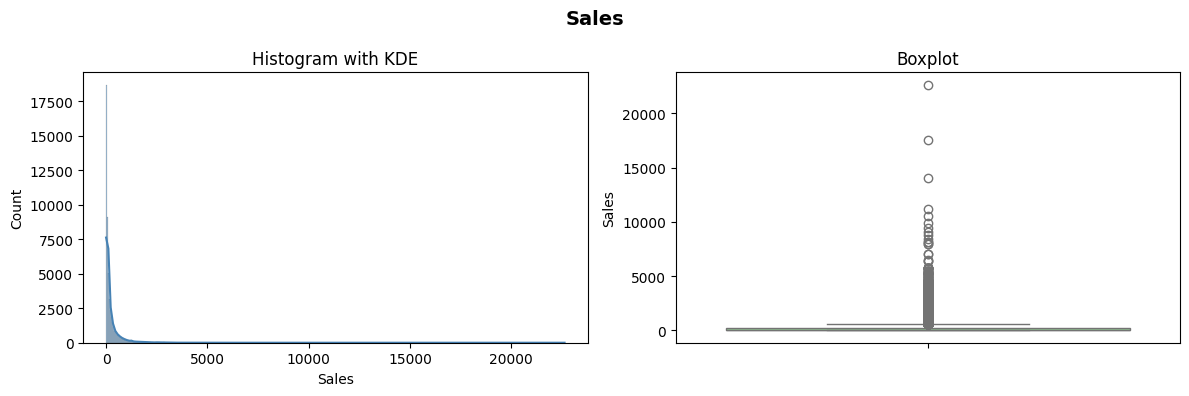

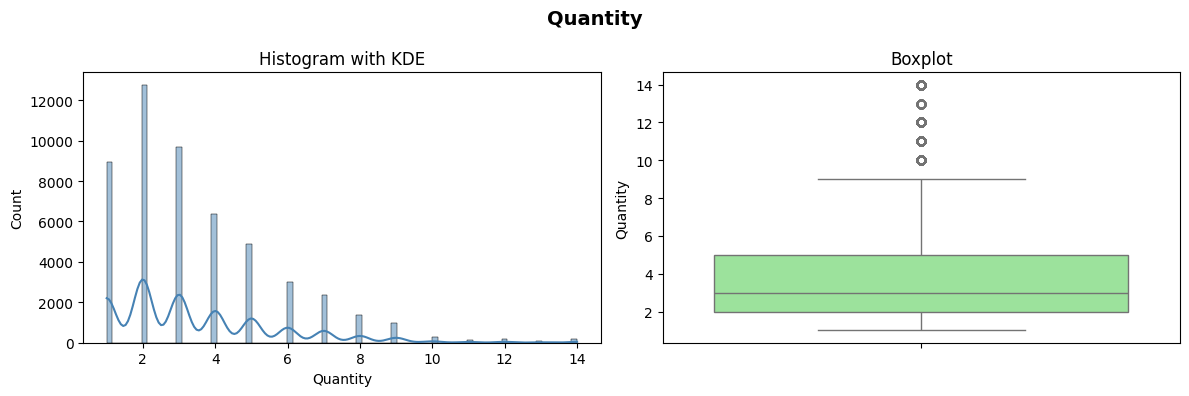

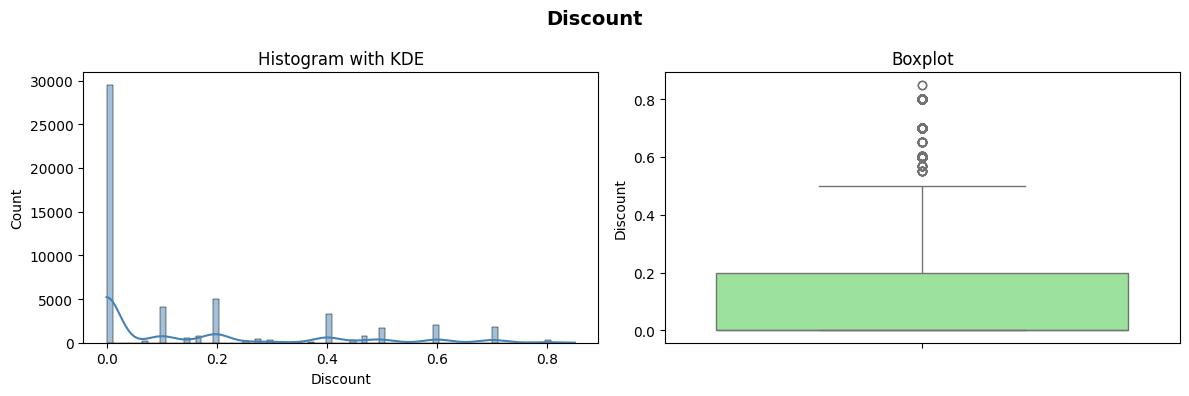

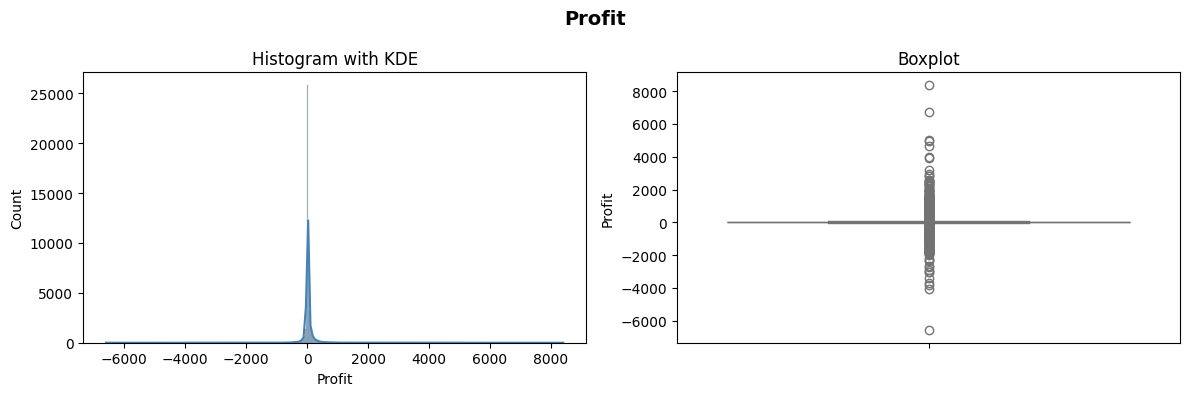

In [89]:
for col in numeric_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f'{col}', fontsize=14, fontweight='bold')

    # Histogram with KDE
    sns.histplot(df1[col], kde=True, ax=axes[0], color='steelblue')
    axes[0].set_title('Histogram with KDE')
    axes[0].set_xlabel(col)

    # Boxplot
    sns.boxplot(y=df1[col], ax=axes[1], color='lightgreen')
    axes[1].set_title('Boxplot')

    plt.tight_layout()
    plt.show()

In [90]:
#Outlier Check using IQR
for col in numeric_cols:
    Q1 = df1[col].quantile(0.25)
    Q3 = df1[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df1[(df1[col] < Q1 - 1.5 * IQR) | (df1[col] > Q3 + 1.5 * IQR)]
    print(f"{col}: {len(outliers)} outliers detected")

Sales: 5655 outliers detected
Quantity: 877 outliers detected
Discount: 4172 outliers detected
Profit: 9755 outliers detected


In [91]:
#Frequency Distribution for Categorical Variables
for col in categorical_cols:
    print(f"\n====={col}====")
    counts = df1[col].value_counts(dropna = False)
    percentages = round(df1[col].value_counts(normalize = True, dropna = False) *100, 2)

    summary = pd.DataFrame({
        "count": counts,
        "percentage": percentages
    })

    display(summary)


=====Segment====


,count,percentage
Segment,,
Consumer,26512,51.70
Corporate,15428,30.08
Home Office,9342,18.22



=====Sub.Category====


,count,percentage
Sub.Category,,
Binders,6152,12.00
Storage,5058,9.86
Art,4880,9.52
Paper,3535,6.89
Chairs,3434,6.70
Phones,3357,6.55
Furnishings,3170,6.18
Accessories,3075,6.00
Labels,2605,5.08



=====Market====


...

,count,percentage
Category,,
Office Supplies,31265,60.97
Technology,10141,19.77
Furniture,9876,19.26



=====Ship.Mode====


,count,percentage
Ship.Mode,,
Standard Class,30772,60.01
Second Class,10308,20.10
First Class,7503,14.63
Same Day,2699,5.26



=====Order.Priority====


,count,percentage
Order.Priority,,
Medium,29428,57.38
High,15498,30.22
Critical,3932,7.67
Low,2424,4.73
